In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 5)

#### **Dataset :**

`price_csv` 
- `price_DA` : electricity price set the day before - our feature.
- `price_ID` : electricity price 2h before delivery - our target. 
- Granularity : 30min (GB market trades in half-hour periods).

`INDGEN_DA.csv` / `INDGEN_ID` - Indicative Generation
- Forecasted electricity production (in MW) for each zone of the GB grid.
- `_DA.csv` : forecast made the day before.
- `_ID.csv` : forecast updated 2h before delivery, more accurate.
- Z1, Z2 ... Z17 -> geographical zones, each zone has its own generation and consumption dynamics, while Day-Ahead and Intraday are National Price
- *Example : if a large power plant went offline overnight, `INDGEN_ID` will be lower than `INDGEN_DA` -> signal that the price will go up.*

`MELNGC_DA.csv` / `MELNGC_ID.csv` — Margin to Low National Grid Constraint.
- margin between available generation and demand in each zone.
- A negative value = zone under stress (demands > local generation).
- *Likely the most price-correlated feature: the tighter the margin, the higher the price*

`TSDF_DA.csv` / `TSDF_ID.csv` — Transmission System Demand Forecast
- Forecasted electricity demand (in MW) for each zone.
- Same mechanism than Indicative Generation. 
- *Example : if actual demand is stronger than expected -> price goes up*

## **(0) Loading & Cleaning Data**

In [26]:
# Load target file

prices = pd.read_csv('dataset/prices.csv', parse_dates=['GMT_PERIOD_START_DATETIME'])
prices = prices.rename(columns={'GMT_PERIOD_START_DATETIME': 'timestamp'})
prices = prices.sort_values('timestamp').reset_index(drop=True)

print(prices.shape)
prices.head()

(87696, 3)


,timestamp,price_DA,price_ID
0,2020-01-01 00:00:00,43.45,35.28
1,2020-01-01 00:30:00,43.45,37.01
2,2020-01-01 01:00:00,41.12,37.78
3,2020-01-01 01:30:00,41.12,35.60
4,2020-01-01 02:00:00,29.98,31.70


In [27]:
# load features file

feature_files = {
    'indgen_da': 'dataset/INDGEN_DA.csv',
    'indgen_id': 'dataset/INDGEN_ID.csv',
    'melngc_da': 'dataset/MELNGC_DA.csv',
    'melngc_id': 'dataset/MELNGC_ID.csv',
    'tsdf_da':   'dataset/TSDF_DA.csv',
    'tsdf_id':   'dataset/TSDF_ID.csv',
}

dfs = {}

for name, path in feature_files.items():

    df = pd.read_csv(path, parse_dates=['GMT_PERIOD_START_DATETIME'])
    df = df.rename(columns={'GMT_PERIOD_START_DATETIME': 'timestamp'})
    df = df.sort_values('timestamp').reset_index(drop=True)

    # Prefix zone columns to avoid name conflicts when merging: Z1 become indgen_da_Z1 etc.
    zone_cols = [c for c in df.columns if c != 'timestamp']
    df = df.rename(columns={z: f'{name}_{z}' for z in zone_cols})
    dfs[name] = df

for name, df in dfs.items():
    print(f"{name}: {df.shape} / {df['timestamp'].min()} : {df['timestamp'].max()}")

indgen_da: (43848, 18) / 2020-01-01 00:00:00 : 2024-12-31 23:00:00
indgen_id: (43848, 18) / 2020-01-01 00:00:00 : 2024-12-31 23:00:00
melngc_da: (43848, 18) / 2020-01-01 00:00:00 : 2024-12-31 23:00:00
melngc_id: (43848, 18) / 2020-01-01 00:00:00 : 2024-12-31 23:00:00
tsdf_da: (43848, 18) / 2020-01-01 00:00:00 : 2024-12-31 23:00:00
tsdf_id: (43848, 18) / 2020-01-01 00:00:00 : 2024-12-31 23:00:00


In [28]:
# Solve the granularity mismatch : price.csv is at 30min granularity while all feature are hourly

prices['timestamp'] = prices['timestamp'].dt.floor('h')

# For each hour, take the mean of the 2 half-hour periods
prices_hourly = (prices.groupby('timestamp')[['price_DA', 'price_ID']].mean().reset_index())

print(prices.shape[0])
print(prices_hourly.shape[0])
prices_hourly.head()

87696
43848


,timestamp,price_DA,price_ID
0,2020-01-01 00:00:00,43.45,36.145
1,2020-01-01 01:00:00,41.12,36.690
2,2020-01-01 02:00:00,29.98,32.135
3,2020-01-01 03:00:00,27.10,28.475
4,2020-01-01 04:00:00,26.37,30.760


In [29]:
# Merge everything into one dataframe 

df = prices_hourly.copy()

for name, feature_df in dfs.items():
    df = df.merge(feature_df, on='timestamp', how='inner')

print(df.shape)
df.head()

(43848, 105)


,timestamp,price_DA,price_ID,indgen_da_Z1,indgen_da_Z10,indgen_da_Z11,indgen_da_Z12,indgen_da_Z13,indgen_da_Z14,indgen_da_Z15,...,tsdf_id_Z16,tsdf_id_Z17,tsdf_id_Z2,tsdf_id_Z3,tsdf_id_Z4,tsdf_id_Z5,tsdf_id_Z6,tsdf_id_Z7,tsdf_id_Z8,tsdf_id_Z9
0,2020-01-01 00:00:00,43.45,36.145,1171.5,1724.5,0.0,2214.0,2106.0,408.0,875.0,...,2089.0,1374.5,275.0,27.5,247.0,550.0,1456.5,1346.5,2474.0,3380.5
1,2020-01-01 01:00:00,41.12,36.690,1199.5,1724.0,0.0,2109.5,2085.0,403.0,830.5,...,2081.5,1369.5,274.0,27.5,246.0,548.0,1452.0,1341.5,2465.5,3368.5
2,2020-01-01 02:00:00,29.98,32.135,1212.0,1724.5,0.0,2027.0,2068.5,403.0,706.0,...,1962.5,1291.0,258.0,26.0,232.5,516.0,1368.5,1265.5,2324.0,3351.0
3,2020-01-01 03:00:00,27.10,28.475,1226.5,1722.0,0.0,1935.5,2062.5,403.0,596.0,...,1848.5,1215.5,243.0,24.5,218.5,486.5,1288.5,1192.0,2188.5,3840.0
4,2020-01-01 04:00:00,26.37,30.760,1246.5,1722.0,0.0,1832.0,2060.5,403.0,535.0,...,1768.0,1163.5,233.0,23.0,209.5,465.5,1233.5,1140.0,2094.0,3469.5


In [30]:
# Quick Check for any missing / duplicate values

# Missing values
missing = df.isnull().sum()
print("missing values:")
print(missing[missing > 0])

# Duplicate timestamps
duplicates = df['timestamp'].duplicated().sum()
print(f"Duplicated timestamps: {duplicates}")

df.info()

missing values:
price_DA          28
indgen_da_Z1     469
indgen_da_Z10    469
indgen_da_Z11    469
indgen_da_Z12    468
                ... 
tsdf_da_Z5        38
tsdf_da_Z6        38
tsdf_da_Z7        38
tsdf_da_Z8        38
tsdf_da_Z9        38
Length: 69, dtype: int64
Duplicated timestamps: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43848 entries, 0 to 43847
Columns: 105 entries, timestamp to tsdf_id_Z9
dtypes: datetime64[ns](1), float64(104)
memory usage: 35.1 MB


In [31]:
# As we are working with time series, I used forward fill to address missing values (last value is the best possible estimation..)

df = df.sort_values('timestamp')
df = df.ffill()

print(df.isnull().sum().sum(), "missing values")

0 missing values


## **(1) Exploratory Data Analysis**

#### **The ID / DA Spread**

Before plotting anything, we compute the spread (price_ID - price_DA) to isolate what actually changed between the day-ahead forecast and the intra-day settlement.

In [32]:
df['spread'] = df['price_ID'] - df['price_DA']
print(df['spread'].describe())

count    43848.000000
mean        -3.321731
std         40.655374
min      -1899.880000
25%        -10.940000
50%         -1.235000
75%          7.510000
max       1082.455000
Name: spread, dtype: float64


**Insights :**
- **Mean = -3.32 £/MWh** → on average, the ID price settles slightly below the DA price, suggesting the DA market systematically prices in a small risk premium.
- **Std = 40.66** → the dispersion is 12 times the absolute mean -3.32, meaning the spread is extremely noisy and hard to predict on average.
- **50% of cases** : spread stays between -10.94 and +7.51 £/MWh → DA and ID are close most of the time.
- **Min = -1899 / Max = +1082** → massive outliers (presence of extreme events) these are structurally hard to predict and the model will likely struggle on them.

Lets plot the spread :

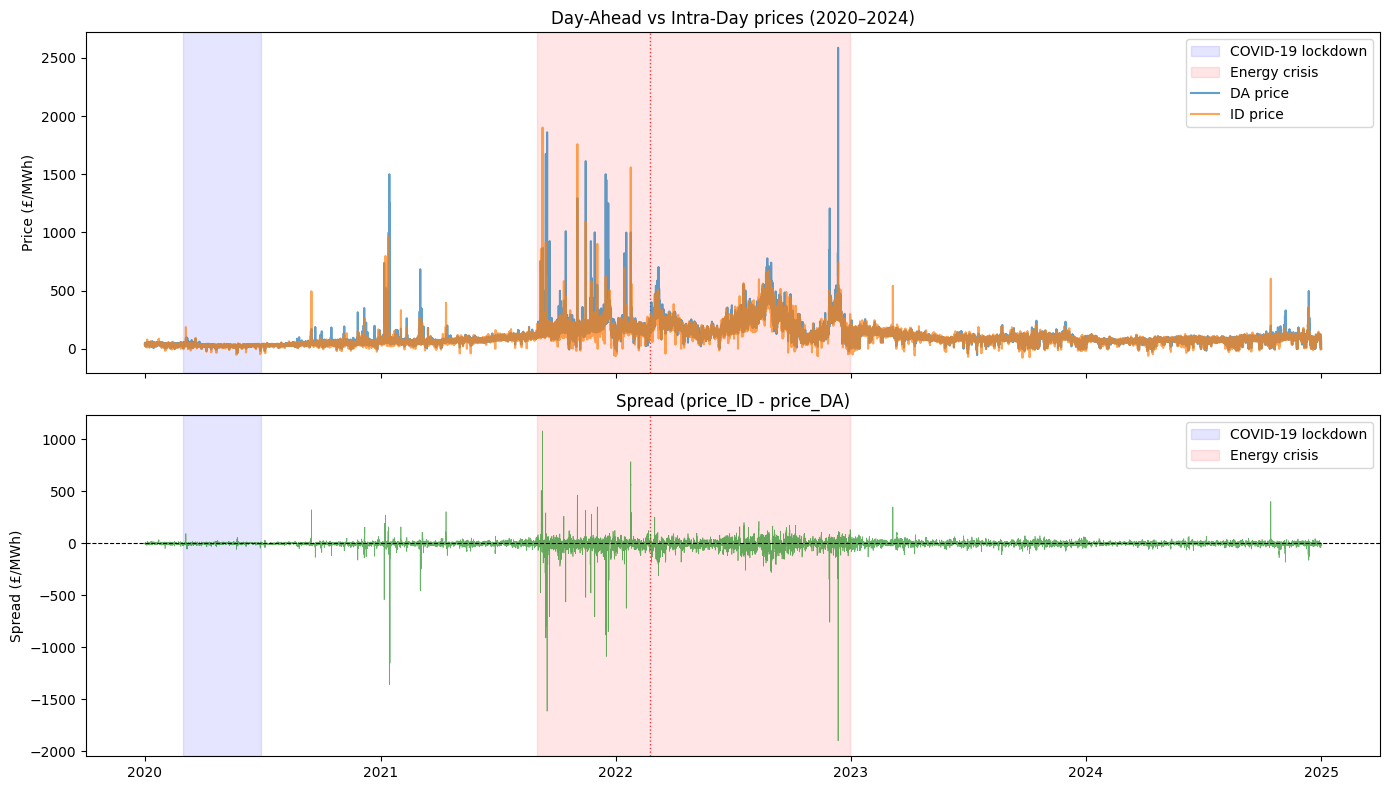

In [33]:
# Made with AI

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Define periods
periods = [
    {'start': '2020-03-01', 'end': '2020-06-30', 'label': 'COVID-19 lockdown', 'color': 'blue'},
    {'start': '2021-09-01', 'end': '2022-12-31', 'label': 'Energy crisis',     'color': 'red'},
]

for ax in (ax1, ax2):
    for p in periods:
        ax.axvspan(pd.Timestamp(p['start']), pd.Timestamp(p['end']),
                   color=p['color'], alpha=0.1, label=p['label'])
    # Ukraine invasion : vertical line
    ax.axvline(pd.Timestamp('2022-02-24'), color='red', linewidth=1,
               linestyle=':', alpha=0.8)

# Top : DA vs ID
ax1.plot(df['timestamp'], df['price_DA'], label='DA price', alpha=0.7)
ax1.plot(df['timestamp'], df['price_ID'], label='ID price', alpha=0.7)
ax1.set_title('Day-Ahead vs Intra-Day prices (2020–2024)')
ax1.set_ylabel('Price (£/MWh)')
ax1.legend()

# Bottom : spread
ax2.plot(df['timestamp'], df['spread'], color='green', alpha=0.6, linewidth=0.5)
ax2.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax2.set_title('Spread (price_ID - price_DA)')
ax2.set_ylabel('Spread (£/MWh)')
ax2.legend()

plt.tight_layout()
plt.show()

**Insights :**
- The spread is near zero most of the time
- During the energy crisis (red), spread volatility explodes in both directions, driven by unpredictable supply shocks
- The Ukraine invasion (dotted line) sits at the peak of the worst spread cluster
- Post-2023, the market returns to a calm regime with a tight spread
- **Implication :** the model's value will lies precisely in volatile periods when the spread is non-zero and supply/demand features carry real signal. However, extreme shocks such as plant outages or geopolitical events remain structurally hard to predict regardless of the features available.

#### **Hourly patterns**

**Goal :** Identify whether the spread follows a structural intraday pattern that the model can learn from.


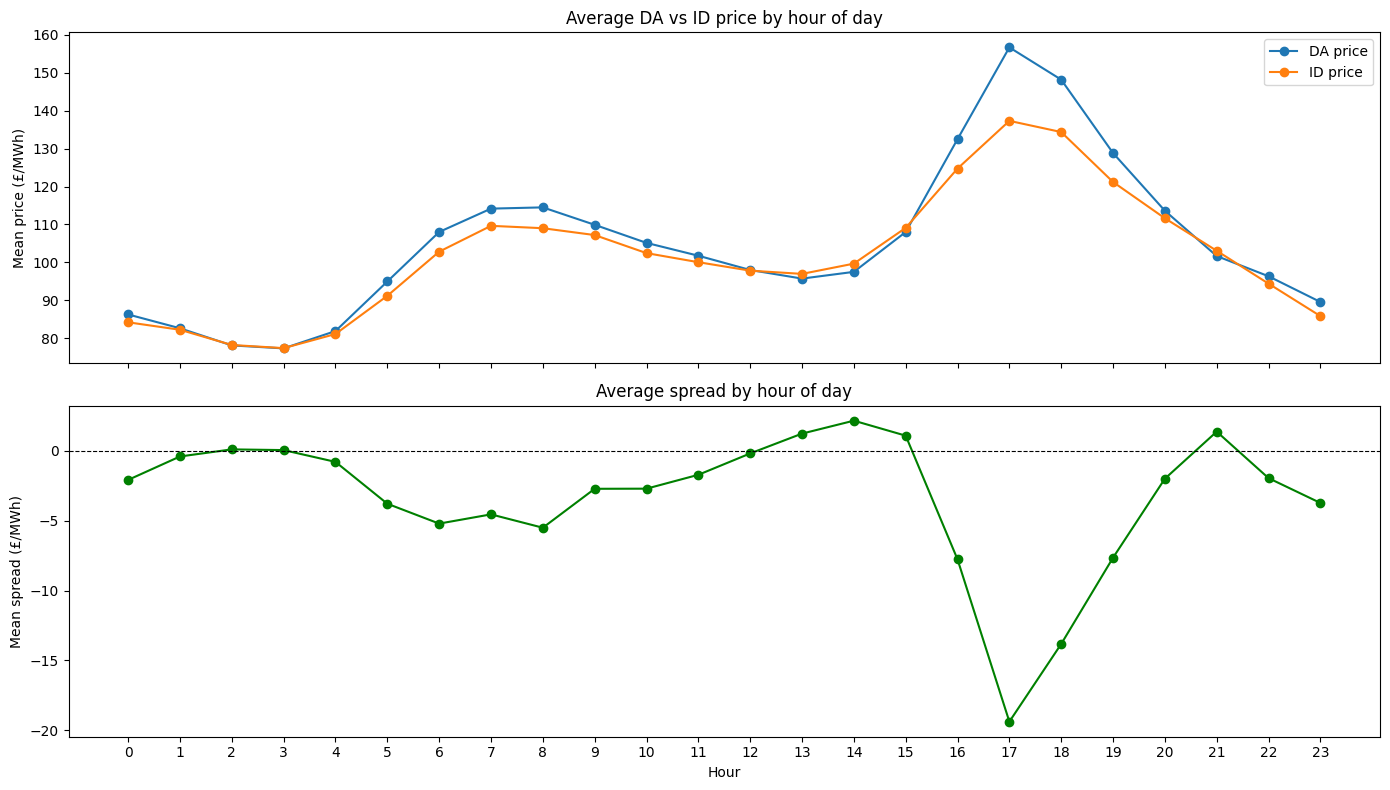

In [34]:
# Done with AI

df['hour']   = df['timestamp'].dt.hour
df['spread'] = df['price_ID'] - df['price_DA']

hourly_da     = df.groupby('hour')['price_DA'].mean()
hourly_id     = df.groupby('hour')['price_ID'].mean()
hourly_spread = df.groupby('hour')['spread'].mean()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Top : DA vs ID by hour
ax1.plot(hourly_da.index, hourly_da.values, marker='o', label='DA price')
ax1.plot(hourly_id.index, hourly_id.values, marker='o', label='ID price')
ax1.set_title('Average DA vs ID price by hour of day')
ax1.set_ylabel('Mean price (£/MWh)')
ax1.legend()

# Bottom : spread by hour
ax2.plot(hourly_spread.index, hourly_spread.values, marker='o', color='green')
ax2.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax2.set_title('Average spread by hour of day')
ax2.set_xlabel('Hour')
ax2.set_ylabel('Mean spread (£/MWh)')
ax2.set_xticks(range(24))

plt.tight_layout()
plt.show()

**Key Insights :**
- The DA market systematically overestimates prices across almost all hours the spread is negative for most of the day
- Hour 17 is the sharpest anomaly : spread drops to -20 £/MWh, meaning the DA consistently overprices the evening peak, likely because renewable output in late afternoon is regularly stronger than forecasted
- Midday (12h-15h) is the best-balanced window — spread near zero, DA and ID agree
- **Implication :** `hour` is a key feature, the spread follows a reproducible daily cycle the model can exploit

#### **Impact of margin on the spread**

**Goal :** Check whether the national generation margin (Available Generation - Transmission Demand) explains spread volatility.


In [35]:
# Sum all MELNGC_ID zone columns to get total national margin
melngc_cols = [c for c in df.columns if c.startswith('melngc_id_')]
df['total_margin'] = df[melngc_cols].sum(axis=1)

print(df['total_margin'].describe())

count    43848.000000
mean     26959.139003
std       5396.126439
min      10987.500000
25%      22808.875000
50%      27076.500000
75%      30890.750000
max      43818.000000
Name: total_margin, dtype: float64


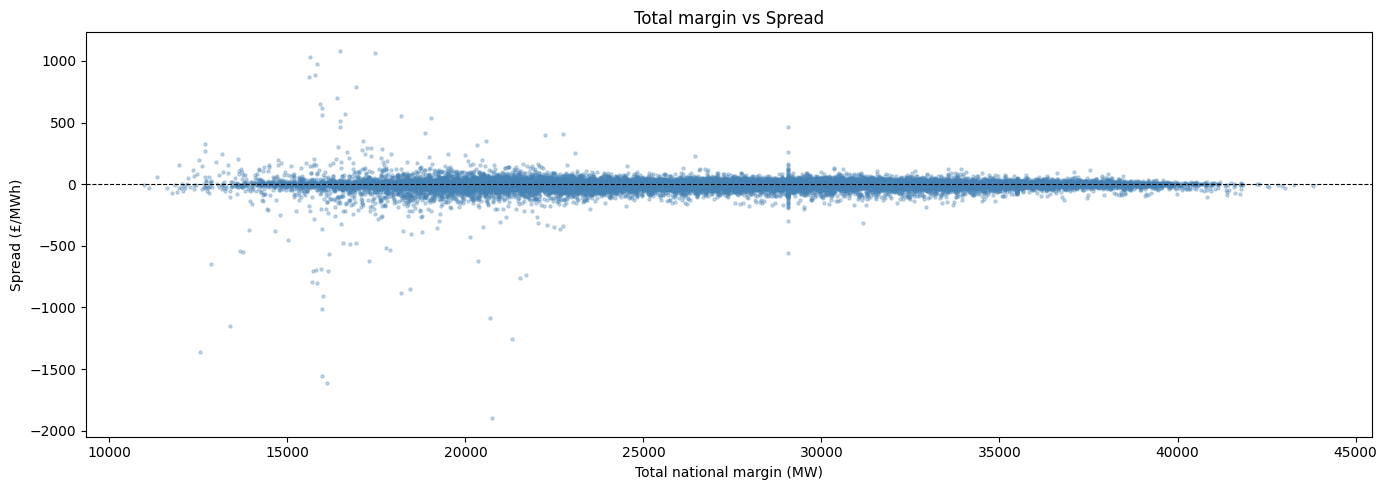

In [36]:
fig, ax = plt.subplots()

ax.scatter(df['total_margin'], df['spread'],
           alpha=0.3, s=5, color='steelblue')

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Total margin vs Spread')
ax.set_xlabel('Total national margin (MW)')
ax.set_ylabel('Spread (£/MWh)')

plt.tight_layout()
plt.show()

**Insights :**
- National margin is always positive (11–44 GW), no blackout scenario in the dataset.
- The funnel shape confirms that low margin = high spread uncertainty, but the direction (positive or negative) depends on whether the DA market over or underestimated the situation
- **Implication :** margin encodes market risk level, not spread direction. A non-linear model is needed to exploit this signal

#### **Spread seasonality**

**Goal :** Check whether the spread follows a seasonal pattern across the year.

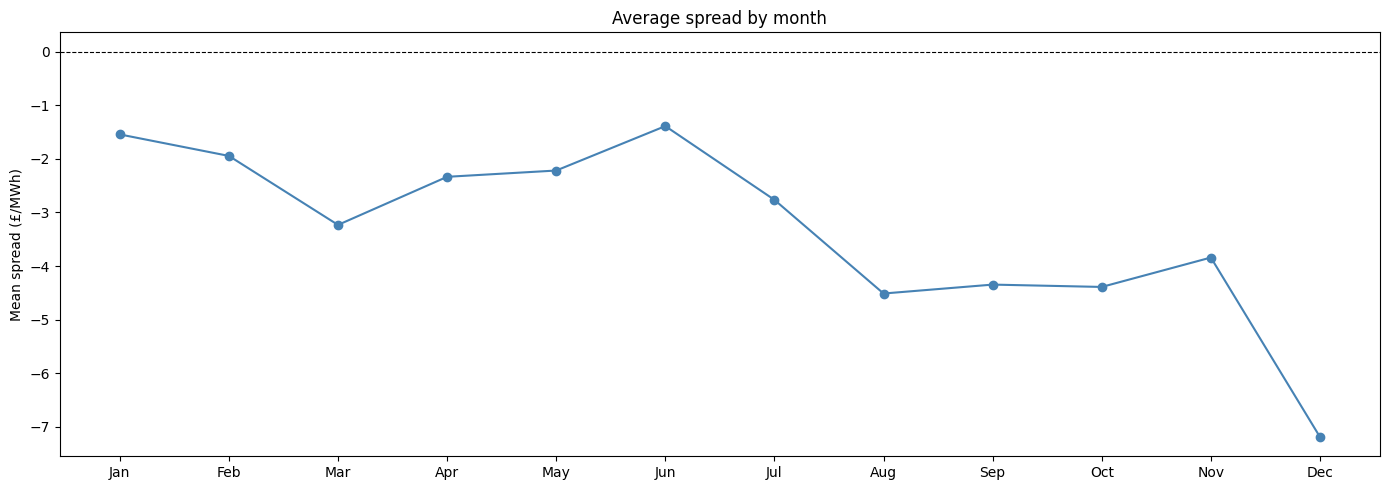

In [37]:
# Made with AI

df['month'] = df['timestamp'].dt.month

monthly_spread = df.groupby('month')['spread'].mean()

month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

fig, ax = plt.subplots()
ax.plot(monthly_spread.index, monthly_spread.values, marker='o', color='steelblue')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_labels)
ax.set_title('Average spread by month')
ax.set_ylabel('Mean spread (£/MWh)')
plt.tight_layout()
plt.show()


**Insights :**
- The spread is negative every month, the DA market systematically overestimates the ID price year-round.
- Two distinct regimes: Jan–Jun spread is mild (-1.5 to -3.5), Jul–Dec widens progressively to a peak of -7.5 £/MWh in December.
- December stands out at -7.5 £/MWh : high forecast uncertainty (low solar, variable wind, peak heating demand) combined with the extreme Dec 2021/2022 crisis years pulling the 5-year average down.
- **Implication :** `month` and `season` are useful features, particularly to distinguish the calm summer regime from the volatile winter one.


#### **Negative prices & outliers**

**Goal :** Quantify how often prices go negative and what it implies for the DA/ID relationship.

In [38]:
neg_da = (df['price_DA'] < 0).sum()
neg_id = (df['price_ID'] < 0).sum()
total  = len(df)

print(f"Negative DA prices : {neg_da} ({100 * neg_da / total:.2f}% of hours)")
print(f"Negative ID prices : {neg_id} ({100 * neg_id / total:.2f}% of hours)")

Negative DA prices : 396 (0.90% of hours)
Negative ID prices : 719 (1.64% of hours)


**Insights :**
- Negative prices are rare but real, under 2% of hours
- ID has almost 2× more negative prices than DA (1.64% vs 0.90%), the DA market underestimates renewable surpluses.
- This partly explains the negative average spread, but given the low frequency of these events, adding a dedicated feature would add complexity without meaningful impact on overall model performance


#### **Distribution of DA / ID prices**

**Goal :** Understand the overall price distribution and confirm the presence of extreme values.

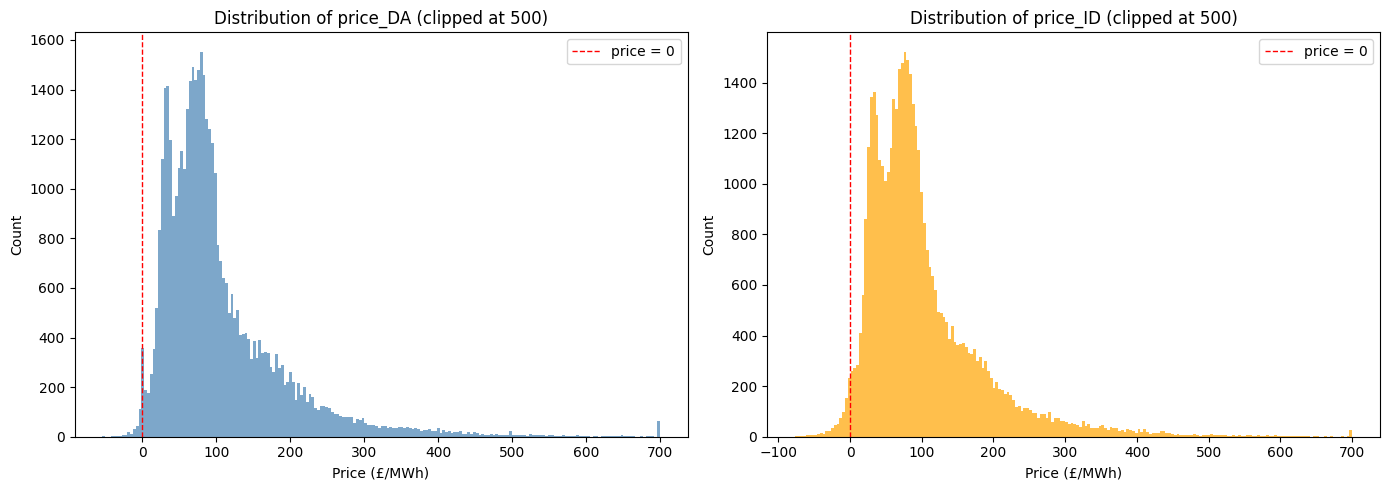

In [39]:
# Made with AI

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, color in zip(axes, ['price_DA', 'price_ID'], ['steelblue', 'orange']):
    # Clip at 500 to see the main distribution (ignoring extreme outliers)
    data = df[col].clip(upper=700)
    ax.hist(data, bins=200, color=color, alpha=0.7, edgecolor='none')
    ax.axvline(0, color='red', linewidth=1, linestyle='--', label='price = 0')
    ax.set_title(f'Distribution of {col} (clipped at 500)')
    ax.set_xlabel('Price (£/MWh)')
    ax.set_ylabel('Count')
    ax.legend()

plt.tight_layout()
plt.show()

*NB : The spike at 500 is a visual artefact of `clip(upper=500)`, extreme values up to 1900 £/MWh exist in the data*

**Insights :**
- Both distributions are **bimodal** : two distinct price regimes coexist in the data, consistent with the time series plot: the calm periods (2020, 2023–2024) cluster around 30–50 £/MWh and the energy crisis (2021–2022) around 70–150 £/MWh.
- ID extends further left (down to -100 £/MWh) confirming it captures renewable surpluses that DA misses.


#### **Correlation**

**Goal :** Quantify the linear relationships between features and the target, and detect redundancy between features.

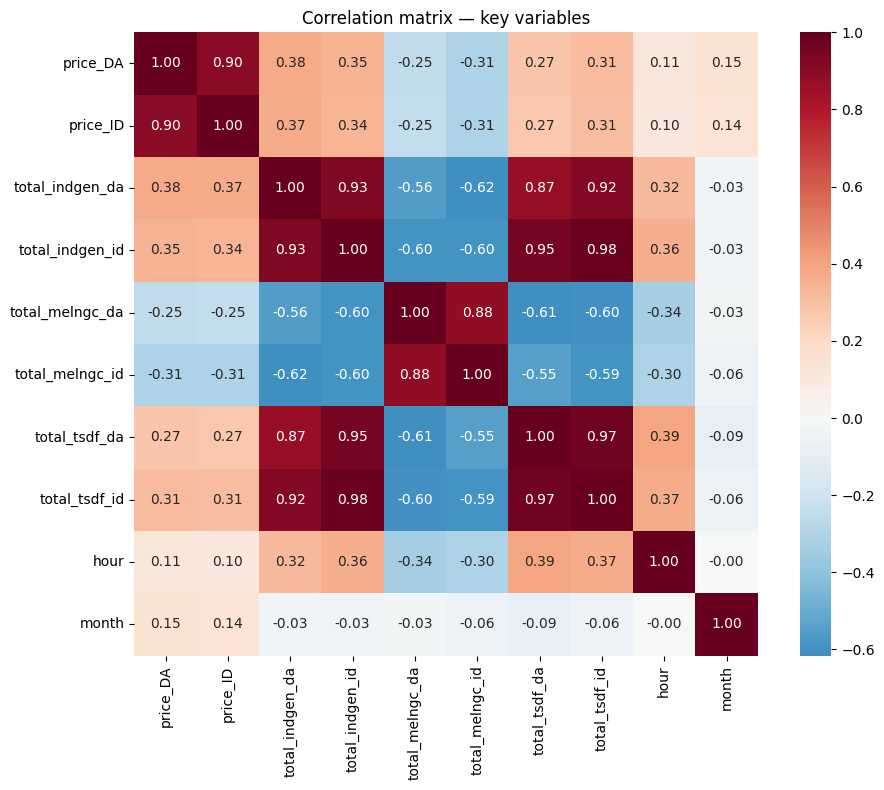

In [41]:
# Aggregate all zone columns into national totals
zone_prefixes = ['indgen_da', 'indgen_id', 'melngc_da', 'melngc_id', 'tsdf_da', 'tsdf_id']

for prefix in zone_prefixes:
    cols = [c for c in df.columns if c.startswith(prefix + '_')]
    df[f'total_{prefix}'] = df[cols].sum(axis=1)

# Build a clean DataFrame with just the key variables
corr_cols = [
    'price_DA', 'price_ID',
    'total_indgen_da', 'total_indgen_id',
    'total_melngc_da', 'total_melngc_id',
    'total_tsdf_da',   'total_tsdf_id',
    'hour', 'month'
]

corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=ax, square=True)
ax.set_title('Correlation matrix — key variables')
plt.tight_layout()
plt.show()

**Insights :**
- price_DA : 0.90 with price_ID : the dominant signal by far, no other feature comes close, confirming the model will anchor on the DA price
- MELNGC is negatively correlated with prices (-0.25 / -0.31) : more margin = more available supply = lower prices, with ID slightly stronger than DA
- INDGEN and TSDF are positively correlated (0.27–0.37) : generation and demand rise together during high-demand hours when prices are naturally high
- Strong multicollinearity between DA and ID versions of each indicator (0.88–0.97), keeping both as raw features would be redundant.
- `hour` and `month` show weak linear correlation (0.10–0.15) but have a strong non-linear effect on the spread (seen earlier).


## **(2) Model Description**



**What the EDA told us :**

- **price_DA is the dominant signal** (0.90 correlation with price_ID) — any model should anchor on it
- **The spread is mostly small but occasionally extreme** — the relationship is highly non-linear, with a funnel-shaped dependency on margin (low margin = high uncertainty, in both directions)
- **Time structure matters** — the spread follows a reproducible daily cycle (sharp dip at hour 17) and a seasonal pattern (worst in December)
- **Features are highly redundant** between their DA and ID versions, suggesting deltas (ID - DA) as the informative signal
- **Two market regimes coexist** (calm years vs 2021–2022 crisis), creating a real overfitting risk

**Why XGBoost**

These findings point away from a linear model and towards a **gradient-boosted tree model (XGBoost)** :

- **Captures non-linearities natively** — essential given the funnel-shaped margin/spread relationship
- **Robust to outliers** — extreme prices (up to 1900 £/MWh) won't break training
- **Handles feature interactions** — e.g. low margin *during* an evening peak *in winter*
- **Interpretable** via feature importance — valuable for explaining results to traders
- **Fast to train** on ~44k rows, no heavy tuning required

**Benchmarking strategy**

To find if XGBoost actually adds value, we compare it against two baselines :

1. **Naive** : predict `price_ID = price_DA` — the natural floor any model must beat
2. **Linear Regression** : tests whether the relationships can be captured linearly

If XGBoost can't beat these, the added complexity isn't justified.

#### **Feature Engineering : Time-based features** 

We build calendar features to let the model capture the daily and seasonal spread patterns identified in the EDA (notably the sharp evening dip at hour 17 and the December seasonality).

In [46]:
# Day of week (0=Monday, 6=Sunday) and a weekend flag
df['day_of_week'] = df['timestamp'].dt.dayofweek
df['is_weekend']  = (df['day_of_week'] >= 5).astype(int)

# Map each month to a season (0=Winter, 1=Spring, 2=Summer, 3=Autumn)
def get_season(month):
    if month in [12, 1, 2]:  return 0 # Winter
    if month in [3, 4, 5]:   return 1 # Spring
    if month in [6, 7, 8]:   return 2 # Summer
    return 3 # Autumn

df['season'] = df['month'].apply(get_season)

# Peak-hour flag : the evening demand peak (16-19h) where the EDA showed a sharp spread dip
df['is_peak_hour'] = df['hour'].isin([16, 17, 18, 19]).astype(int)

# Quick check on the new features
display(df[['timestamp', 'hour', 'month', 'day_of_week', 'is_weekend', 'season', 'is_peak_hour']].head(24))

,timestamp,hour,month,day_of_week,is_weekend,season,is_peak_hour
0,2020-01-01 00:00:00,0,1,2,0,0,0
1,2020-01-01 01:00:00,1,1,2,0,0,0
2,2020-01-01 02:00:00,2,1,2,0,0,0
3,2020-01-01 03:00:00,3,1,2,0,0,0
4,2020-01-01 04:00:00,4,1,2,0,0,0
5,2020-01-01 05:00:00,5,1,2,0,0,0
6,2020-01-01 06:00:00,6,1,2,0,0,0
7,2020-01-01 07:00:00,7,1,2,0,0,0
8,2020-01-01 08:00:00,8,1,2,0,0,0
9,2020-01-01 09:00:00,9,1,2,0,0,0


#### **Feature Engineering : DA/ID Delta features** 

We turn the redundant DA/ID feature pairs into a single informative signal : the surprise between what the market expected the day before and what it sees 2h ahead.

In [48]:
df['delta_indgen'] = df['total_indgen_id'] - df['total_indgen_da']
df['delta_melngc'] = df['total_melngc_id'] - df['total_melngc_da']
df['delta_tsdf']   = df['total_tsdf_id']   - df['total_tsdf_da']

print(df[['delta_indgen', 'delta_melngc', 'delta_tsdf']].describe())

       delta_indgen  delta_melngc    delta_tsdf
count  43848.000000  43848.000000  43848.000000
mean    1765.005462   -691.569718   1219.072546
std     2369.607466   2661.086131   1422.044301
min   -14040.000000 -20790.500000  -4841.000000
25%      216.500000  -2085.500000    256.000000
50%     1467.500000   -387.500000    959.000000
75%     3152.500000   1026.500000   1924.625000
max    21086.500000   9735.500000  12036.000000


#### **Feature Engineering : Final feature set** 

In [50]:
feature_cols = [
    # The most important signal
    'price_DA',
    # Time features
    'hour', 'month', 'day_of_week', 'is_weekend', 'season', 'is_peak_hour',
    # National totals at ID time
    'total_indgen_id', 'total_melngc_id', 'total_tsdf_id',
    # Deltas : the surprise between DA and ID
    'delta_indgen', 'delta_melngc', 'delta_tsdf',
]

X = df[feature_cols]
y = df['price_ID']

print(f"Features : {X.shape[1]}")
print(f"Samples : {X.shape[0]}")


Features : 13
Samples : 43848


#### **Model Training : Train / test split** 

Before training, we split the data chronologically and use 2024 as the test set and train on 2020–2023. Testing on the calm post-crisis year gives the most realistic view of how the model would perform if deployed today, while still learning from the volatile crisis period.

In [52]:
cutoff = pd.Timestamp('2024-01-01')

train = df[df['timestamp'] < cutoff]   # 2020-2023
test  = df[df['timestamp'] >= cutoff]  # 2024

X_train = train[feature_cols]
y_train = train['price_ID']

X_test = test[feature_cols]
y_test = test['price_ID']

print(f"Train : {len(train)} samples")
print(f"Test  : {len(test)} samples")


Train : 35064 samples
Test  : 8784 samples


#### **Model Training : Evaluation metrics** 

We use MAE, RMSE and R² to evaluate the different models

In [54]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)      
    rmse = mean_squared_error(y_true, y_pred) ** 0.5 
    r2   = r2_score(y_true, y_pred)    
    print(f"{name:<25} MAE={mae:.2f}  RMSE={rmse:.2f}  R²={r2:.3f}")


## **(3) Prediction Results**

#### **Baseline 0 : Naive (ID = DA)**

In [55]:
y_pred_naive = X_test['price_DA']

evaluate("Naive (ID = DA)", y_test, y_pred_naive)

Naive (ID = DA)           MAE=10.16  RMSE=15.94  R²=0.737


Predicting `price_ID = price_DA` already explains 73.7% of the variance : floor every model must beat.

#### **Baseline 1 : Linear Regression**

In [56]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

evaluate("Linear Regression", y_test, y_pred_lr)


Linear Regression         MAE=11.01  RMSE=16.41  R²=0.722


The linear model does worse than the naive baseline, likely a sign that linear coefficients fitted on the volatile 2020–2023 period don't transfer well to the calm 2024 regime.

#### **Our model : XGBoost**

In [ ]:
from xgboost import XGBRegressor

# First attempt : reasonable defaults, no regularisation, no early stopping

xgb = XGBRegressor(
    n_estimators=500,     
    learning_rate=0.05,   
    max_depth=6,
    random_state=42,
    verbosity=0
)

xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

evaluate("XGBoost", y_test, y_pred_xgb)


XGBoost                   MAE=11.09  RMSE=17.12  R²=0.697


Out of the box, XGBoost lands below both baselines. As we'll see, the model is overfitting the crisis years rather than learning a signal that transfers to 2024.

In [62]:
# overfit check : compare train vs test performance

y_pred_xgb_train = xgb.predict(X_train)
evaluate("XGBoost (train)", y_train, y_pred_xgb_train) # how well it fits data it has seen
evaluate("XGBoost (test) ", y_test,  y_pred_xgb) # how well it generalises to 2024


XGBoost (train)           MAE=12.69  RMSE=19.03  R²=0.958
XGBoost (test)            MAE=11.09  RMSE=17.12  R²=0.697


Overfitting confirmed R²=0.958 on train vs 0.697 on test. The model memorised the extreme 2021–2022 crisis patterns instead of learning a transferable signal, so it collapses on the calm 2024 market. 

The fix : regularisation + early stopping with a validation set.


In [63]:
# Use 2023 as a validation set to stop training at the optimal number of trees
val_mask = train['timestamp'].dt.year == 2023
X_val = X_train[val_mask]
y_val = y_train[val_mask]
X_tr  = X_train[~val_mask]   # train on 2020-2022
y_tr  = y_train[~val_mask]

xgb2 = XGBRegressor(
    n_estimators=1000, # upper bound : early stopping will pick the real number
    learning_rate=0.05,
    max_depth=4, # reduced from 6 to limit overfitting
    reg_alpha=0.1, # L1 regularisation (sparsity)
    reg_lambda=1.0, # L2 regularisation (shrinks weights)
    early_stopping_rounds=30, # stop if val score doesn't improve for 30 rounds
    verbosity=0,
    random_state=42
)

# eval_set lets the model monitor validation performance during training
xgb2.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)

print(f"Best iteration: {xgb2.best_iteration}")

y_pred_xgb2 = xgb2.predict(X_test)
evaluate("XGBoost v2 (train)", y_train, xgb2.predict(X_train))
evaluate("XGBoost v2 (test) ", y_test,  y_pred_xgb2)


Best iteration: 76
XGBoost v2 (train)        MAE=17.72  RMSE=33.36  R²=0.872
XGBoost v2 (test)         MAE=10.33  RMSE=15.90  R²=0.739


Regularisation closes the gap : train R²=0.872 vs test R²=0.739 (was 0.958/0.697). The model now **just edges past the naive baseline** (0.739 vs 0.737) — a modest but real gain, and the overfitting is largely controlled. **This is our best model.**

As a final try, I tried training only on 2022–2023 to see whether restricting the model to the most recent years (closer to the 2024 regime) would help.

Le meilleur modèle est XGBoost v2 — entraîné sur tout 2020-2023 avec régularisation. Il fait quasi jeu égal avec la baseline naïve sur 2024, ce qui est honnête compte tenu du changement de régime.

Le vrai message pour la présentation : le marché 2024 est si calme que price_ID ≈ price_DA presque tout le temps. Le modèle apportera plus de valeur lors des périodes volatiles — c'est exactement ce qu'on va montrer dans la visualisation des résultats.

#### **Results & Error Analysis : Results summary** 

In [ ]:
# Made with AI

# Collect every model's predictions and score them in one table
models = {
    'Naive (ID = DA)':   y_pred_naive,
    'Linear Regression': y_pred_lr,
    'XGBoost v1':        y_pred_xgb,
    'XGBoost v2':        y_pred_xgb2,
}

results = pd.DataFrame({
    name: {
        'MAE':  mean_absolute_error(y_test, pred),
        'RMSE': mean_squared_error(y_test, pred) ** 0.5,
        'R²':   r2_score(y_test, pred),
    }
    for name, pred in models.items()
}).T.round(3)   # .T to get one row per model

results


,MAE,RMSE,R²
Naive (ID = DA),10.164,15.941,0.737
Linear Regression,11.010,16.406,0.722
XGBoost v1,11.093,17.123,0.697
XGBoost v2,10.335,15.904,0.739


#### **Results & Error Analysis : Predictions vs actual over 2024** 

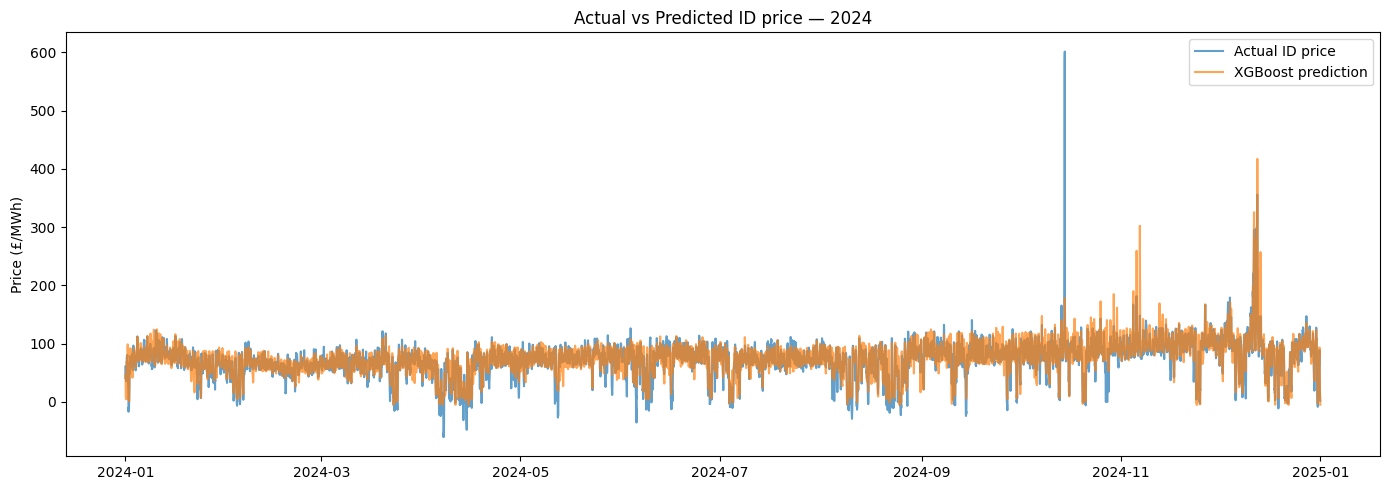

In [65]:
# Made with AI

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(test['timestamp'], y_test.values,    label='Actual ID price',    alpha=0.7)
ax.plot(test['timestamp'], y_pred_xgb2,      label='XGBoost prediction', alpha=0.7)

ax.set_title('Actual vs Predicted ID price — 2024')
ax.set_ylabel('Price (£/MWh)')
ax.legend()
plt.tight_layout()
plt.show()


The model tracks actual prices closely in calm conditions, but visibly underestimates the amplitude of sharp spikes (e.g. the ~600 £/MWh peak in Oct 2024, predicted at ~300), confirming it captures the direction of shocks but not their full magnitude.

#### **Results & Error Analysis : Predicted vs actual scatter** 

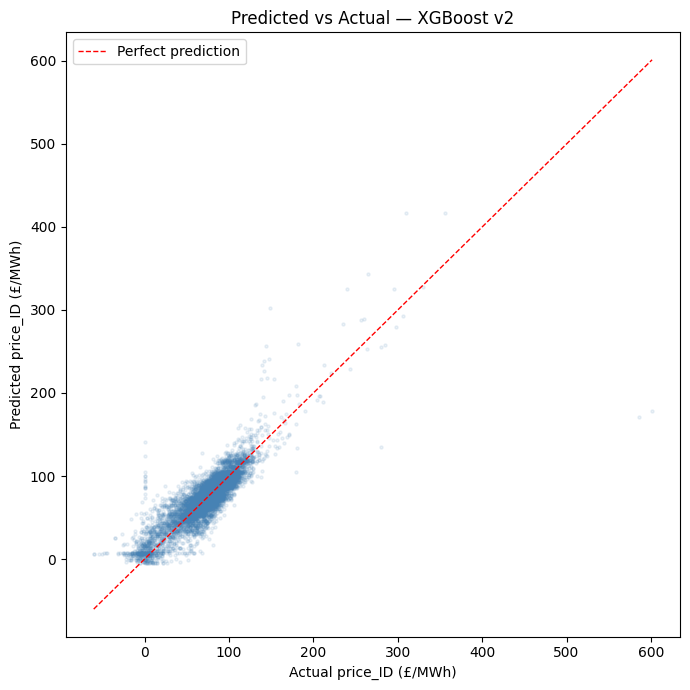

In [67]:
fig, ax = plt.subplots(figsize=(7, 7))

ax.scatter(y_test, y_pred_xgb2, alpha=0.1, s=5, color='steelblue')

# Perfect prediction line
lims = [min(y_test.min(), y_pred_xgb2.min()),
        max(y_test.max(), y_pred_xgb2.max())]
ax.plot(lims, lims, color='red', linewidth=1, linestyle='--', label='Perfect prediction')

ax.set_xlabel('Actual price_ID (£/MWh)')
ax.set_ylabel('Predicted price_ID (£/MWh)')
ax.set_title('Predicted vs Actual — XGBoost v2')
ax.legend()
plt.tight_layout()
plt.show()


Points hug the diagonal in the 0–150 £/MWh range where most hours sit, but fall below it for high prices : the model systematically underestimates extreme values, a structural limit of trees which cannot extrapolate beyond the price range seen in training.

#### **Results & Error Analysis : Features importance** 

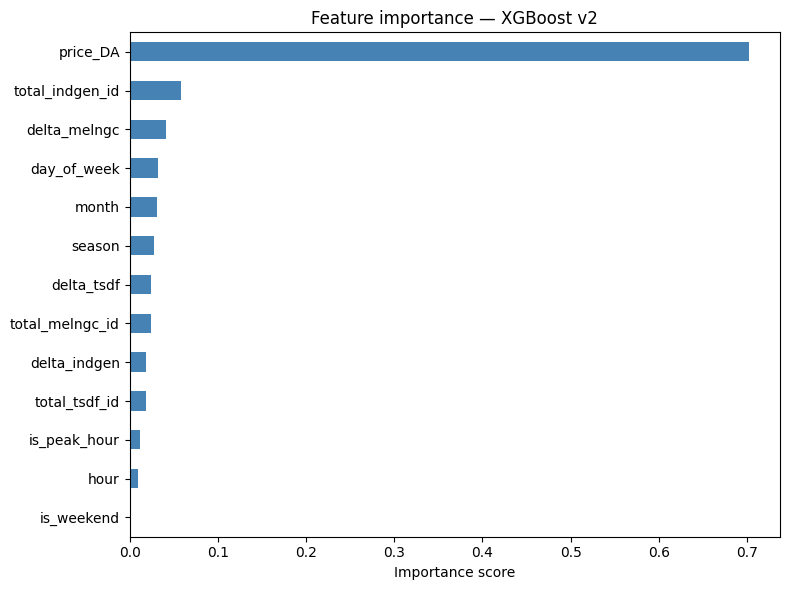

In [68]:
importance = pd.Series(xgb2.feature_importances_, index=feature_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
importance.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Feature importance — XGBoost v2')
ax.set_xlabel('Importance score')
plt.tight_layout()
plt.show()


- `price_DA` dominates (~70%) : the model anchors on the day-ahead price, consistent with the 0.90 correlation found in the EDA. 
- The next strongest signals are `total_indgen_id` and `delta_melngc`, confirming that the margin surprise is the key correction on top of the DA price. 
- Notably, `is_peak_hour` and `hour` rank near zero : the DA price already encodes time-of-day, so our engineered peak-hour feature added little.

#### **Results & Error Analysis : Residual analysis** 

In [70]:
residuals = y_test.values - y_pred_xgb2

print(f"Mean residual : {residuals.mean():.2f} £/MWh")
print(f"Std residual  : {residuals.std():.2f} £/MWh")


Mean residual : -1.66 £/MWh
Std residual  : 15.82 £/MWh


- Mean residual = -1.66 £/MWh → the model is nearly unbiased, on average overpredicting by less than 2 £/MWh. 
- Std = 15.82, consistent with the RMSE (≈ residual std when the mean is close to zero).


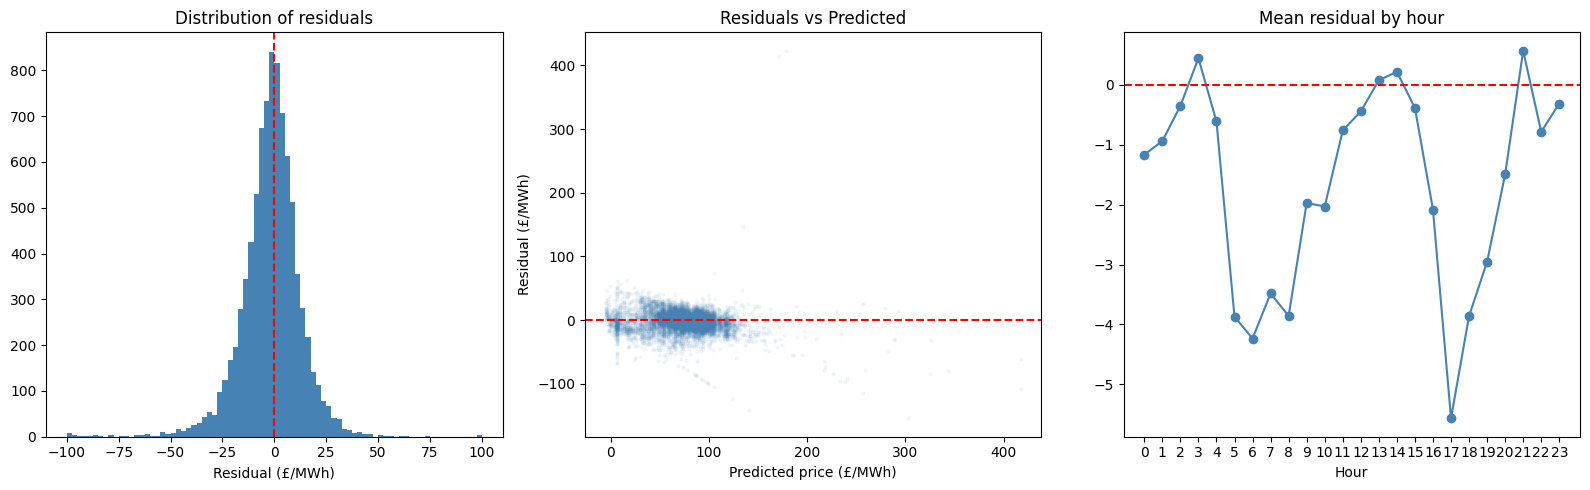

In [ ]:
# Made with AI

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Distribution of residuals (clipped to ±100 to ignore extreme tails)
axes[0].hist(residuals.clip(-100, 100), bins=80, color='steelblue', edgecolor='none')
axes[0].axvline(0, color='red', linestyle='--')
axes[0].set_title('Distribution of residuals')
axes[0].set_xlabel('Residual (£/MWh)')

# 2. Residuals vs predicted — checks if error variance depends on price level
axes[1].scatter(y_pred_xgb2, residuals, alpha=0.05, s=5, color='steelblue')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('Residuals vs Predicted')
axes[1].set_xlabel('Predicted price (£/MWh)')
axes[1].set_ylabel('Residual (£/MWh)')

# 3. Mean residual by hour — checks for time-of-day bias
test_copy = test.copy()
test_copy['residual'] = residuals
hourly_resid = test_copy.groupby('hour')['residual'].mean()

axes[2].plot(hourly_resid.index, hourly_resid.values, marker='o', color='steelblue')
axes[2].axhline(0, color='red', linestyle='--')
axes[2].set_title('Mean residual by hour')
axes[2].set_xlabel('Hour')
axes[2].set_xticks(range(24))

plt.tight_layout()
plt.show()


The residuals are centred and roughly symmetric (left), but their variance grows with the predicted price (middle) : errors are tiny on normal prices and large on extremes (heteroscedasticity). 

By hour (right), the model overestimates the morning ramp (5-7h) and especially the evening peak (-5 £/MWh at 17h), as it still expects the high-price peaks it learned during the crisis years, which 2024 no longer delivers.


## **Conclusion**

**Approach.** We forecast the intra-day price by anchoring on the day-ahead price and adding the surprise between the day-ahead and intra-day forecasts (margin, generation, demand deltas) plus calendar features. XGBoost was chosen for its ability to capture the non-linear, funnel-shaped relationships seen in the EDA.

**Results.** On the held-out 2024 test set, the regularised model (XGBoost v2) reaches R²=0.739, slightly above the naive baseline (R²=0.737). Feature importance confirms the economic intuition : the day-ahead price is the dominant anchor, and the margin surprise (delta_melngc) is the main correction on top of it.

**Why the margin over the baseline is small.** 2024 was an exceptionally calm market : the spread is near zero most of the time, so "price_ID ≈ price_DA" is already close to optimal. The model's real value lies in volatile periods, where the spread is large and the supply/demand features carry genuine signal.

**Limitations.**
- The model cannot extrapolate beyond the price range seen in training, so it underestimates extreme spikes (e.g. the Oct 2024 peak).
- It carries a slight residual bias from the crisis years, overestimating the evening peak in the current calm regime.

**Next steps.**
- Predict the spread (price_ID - price_DA) directly to force the model to focus on the genuinely new information.
- Use walk-forward validation rather than a single split for a more robust estimate.
- Keep per-zone features instead of national aggregates to capture localised stress.
- Add a dedicated mechanism for extreme events (low margin + peak hour + winter).